In [42]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

In [43]:
df = pd.read_csv("../data/drug_discovery_virtual_screening.csv")

In [44]:

df_test_pid_170 = df[df['protein_id'] == "PID_170"]

df_train = df[df['protein_id'] != "PID_170"]
df_train = df_train[df_train['binding_site_size'] < 12]

df_train = df_train.dropna()
df_test_pid_170 = df_test_pid_170.dropna()


In [45]:
X_train = df_train.drop(columns=["active", "compound_id", "protein_id", "binding_affinity"])
y_train = df_train["active"]

In [46]:
X_test_pid_170 = df_test_pid_170.drop(columns=["active", "compound_id", "protein_id", "binding_affinity"])
y_test_pid_170 = df_test_pid_170["active"]

In [47]:
stnd = StandardScaler().set_output(transform='pandas')
X_train = stnd.fit_transform(X_train)
X_test_pid_170 = stnd.transform(X_test_pid_170)

In [55]:
l2 = LogisticRegression(l1_ratio=0, solver="liblinear", C=10, max_iter=10000)
l2.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [56]:
y_pred_pid_170 = l2.predict(X_test_pid_170)

In [57]:
results_pid_170 = pd.concat([y_test_pid_170.reset_index(), pd.Series(y_pred_pid_170, name="predicted"), X_test_pid_170.reset_index(drop=True)], axis=1).set_index("index")

In [58]:
results_pid_170

,active,predicted,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction
index,,,,,,,,,,,,,,,
83,0,0,-0.522797,-2.145683,0.041359,1.617563,-0.037812,-0.160941,-1.189918,-1.389189,-0.639729,-0.288986,5.154903,1.218945,-2.122884
232,0,0,-0.015317,-1.850682,1.491666,2.037523,0.376546,0.719546,1.391574,-0.002837,-1.567336,0.271173,6.973176,-0.358954,-1.924453
251,1,1,0.769779,1.298805,-0.683795,0.777644,0.790903,0.132170,-3.280136,0.887836,1.249391,-0.804061,1.077687,-0.533690,2.167109
335,1,1,-0.188691,0.452053,-1.408949,0.357684,0.376546,0.146371,-0.587707,-0.255840,0.628802,-2.233172,3.051497,-0.264358,0.797475
493,1,1,-0.831523,1.237717,0.766512,0.357684,-0.452170,0.007788,-0.736187,1.246687,1.444583,0.794960,3.503427,-0.923046,2.221160
762,1,1,2.247844,0.741693,0.766512,-1.322154,-0.452170,1.106430,0.667307,1.491945,0.450980,0.849516,-1.113603,-0.445678,1.020987
1044,1,1,-0.211705,0.578173,0.766512,0.357684,0.376546,0.561582,-0.800421,0.172716,0.882036,1.153120,4.276872,-0.495358,1.074866
1306,0,1,-0.030969,0.412971,-1.408949,-0.902195,0.376546,1.369977,-0.249854,-1.435659,0.066299,0.677811,2.083052,1.781827,0.469643
1679,0,0,-0.444809,-0.144073,-0.683795,-0.482235,3.277050,1.664185,1.884214,1.130513,-1.285386,-0.389931,5.382820,-0.830654,-0.629608


In [59]:
def scatter_plot(results): 
    feature1 = "logp"
    feature2 = "protein_pi"

    active = results[results["active"] == 1]
    inactive = results[results["active"] == 0]

    train_active = X_train[y_train==1]
    train_inactive = X_train[y_train==0]

    true_pos = active[active["active"] == active["predicted"]]
    false_pos = active[active["active"] != active["predicted"]]

    true_neg = inactive[inactive["active"] == inactive["predicted"]]
    false_neg = inactive[inactive["active"] != inactive["predicted"]]


    plt.scatter(train_active[feature1], train_active[feature2], alpha=0.06, color = "black")
    plt.scatter(train_inactive[feature1], train_inactive[feature2], alpha=0.06, color="purple")


    plt.scatter(true_pos[feature1], true_pos[feature2], marker="s", s = 100, color="deepskyblue")
    plt.scatter(true_neg[feature1], true_neg[feature2], marker="s", s = 100, color="goldenrod")

    plt.scatter(false_pos[feature1], false_pos[feature2], marker="s", s = 100, color="firebrick")
    plt.scatter(false_neg[feature1], false_neg[feature2], marker="s", s = 100, color="black")

    plt.legend(["Train Active", "Train Inactive", 'True Positive', 'True Negative', 'False Positive', 'False Negative'])

    plt.xlabel(feature1)
    plt.ylabel(feature2)

    plt.title(feature1 + " vs " + feature2)

    plt.show()

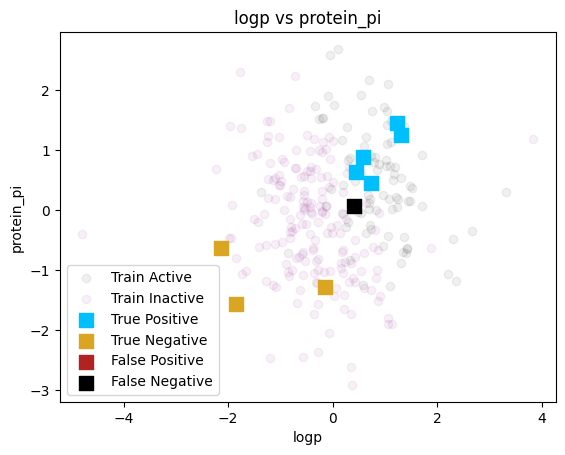

In [60]:
scatter_plot(results_pid_170)